# Weight Pruning — 4-Task Scaling Analysis

Compares **Block-Sparse** (oracle task-aligned) at a fixed budget against **Dense** at six
parameter budgets {1×, 2×, 4×, 8×, 16×, 32×} of the new 4-task base (~19 k weights = 6 dense
units = 24 block-sparse units).

For each setting (stationary `permute_period = 0`, non-stationary `permute_period = 4000`):

1. Step-size sensitivity for block-sparse (one budget).
2. Step-size sensitivity for dense, hue = hidden-unit count.
3. Asymptotic performance vs hidden-unit count, taking the best step-size for each size; the
   horizontal dotted line marks block-sparse asymptotic performance at its best step-size.

For the non-stationary case we also plot full learning curves for the best block-sparse run
and the best (size, step-size) dense run.

Loss is reported per task (`loss / n_tasks`). Non-stationary runs were trained without any
held-out test split, so all panels use training-pool metrics for consistency.


In [35]:
# import os
# os.environ['MLFLOW_TRACKING_URI'] = 'postgresql:///mlflow?host=/var/run/postgresql&port=5433'
# os.environ['OPTUNA_TRACKING_URI'] = 'postgresql:///optuna?host=/var/run/postgresql&port=5433'

# # Run once to fetch from MLflow. Comment out after first run.
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment('paper-weight-pruning-scaling-sweep', output_dir='data', include_seed_runs=True)

INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: postgresql:///mlflow?host=/var/run/postgresql&port=5433
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'paper-weight-pruning-scaling-sweep' (id=29)
INFO:phd.research_utils.scripts.mlflow_download:Found 1977 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 15 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['accuracy', 'accuracy_std', 'active_connections', 'active_units', 'asymptotic_accuracy', 'asymptotic_loss', 'average_loss', 'diverged', 'final_active_connections', 'final_active_units', 'loss', 'loss_std', 'mean_fan_in', 'mean_fan_out', 'path_purity']
Downloading: 100%|██████████| 1977/1977 [03:01<00:00, 10.92it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 1977 param rows to data/paper_weight_pruning_scaling_sweep_params.csv
INFO:phd.research_utils.scripts.mlflow_download:Saved 848284 metric rows to data/paper_weight_pruning_

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

set_matplotlib_style('2-row')
%matplotlib inline

# Block-sparse vs dense palette (only two methods here).
METHOD_ORDER = ['Dense', 'Block-Sparse']
METHOD_PALETTE = get_color_palette(classes=METHOD_ORDER)
# Sequential palette over dense hidden-unit counts.
HIDDEN_SIZES = [6, 12, 24, 48, 96, 192, 384]
SIZE_PALETTE = dict(zip(HIDDEN_SIZES, sns.color_palette('flare', n_colors=len(HIDDEN_SIZES))))
METHOD_PALETTE

SIZE_TO_MULT = {6: '1×', 12: '2×', 24: '4×', 48: '8×', 96: '16×', 192: '32×', 384: '64×'}


def relabel_size_axis():
    """Replace x-axis tick labels (hidden-unit counts) with budget multipliers."""
    ax = plt.gca()
    new_labels = []
    for t in ax.get_xticklabels():
        try:
            new_labels.append(SIZE_TO_MULT[int(float(dt.get_text()))])
        except (ValueError, KeyError):
            new_labels.append(t.get_text())
    ax.set_xticklabels(new_labels)


def save_fig(name):
    """Save current figure as PDF and PNG (with and without legend)."""
    save_fig_versions(name, dir='../figures/pdf/', type='pdf')
    save_fig_versions(name, dir='../figures/png/', type='png')


## Resolve child sweep names

Per-seed child runs only carry a `mlflow.parentRunId` tag — their `sweep_name` falls back to
`'default'` in the download. Look up each child's parent and copy its `sweep_name` over.
The cache auto-invalidates when the params CSV is newer.

In [20]:
def resolve_default_sweep_names(params_path, experiment_name, cache_path):
    df = pd.read_csv(params_path, index_col=0)
    if (df['sweep_name'] == 'default').sum() == 0:
        return
    cache_stale = (
        not os.path.exists(cache_path)
        or os.path.getmtime(cache_path) < os.path.getmtime(params_path)
    )
    if cache_stale:
        import mlflow
        from mlflow.tracking import MlflowClient
        mlflow.set_tracking_uri(os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:///mlruns.db'))
        client = MlflowClient()
        exp = client.get_experiment_by_name(experiment_name)
        all_runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=50000)
        sweep_by = {r.info.run_id: r.data.tags.get('sweep_name', 'default') for r in all_runs}
        rows = []
        for r in all_runs:
            pid = r.data.tags.get('mlflow.parentRunId')
            if pid:
                rows.append({'run_id': r.info.run_id, 'parent_sweep': sweep_by.get(pid, 'default')})
        pd.DataFrame(rows).to_csv(cache_path, index=False)
        print(f'Refreshed parent map: {cache_path} ({len(rows)} children)')

    map_df = pd.read_csv(cache_path)
    map_dict = dict(zip(map_df['run_id'], map_df['parent_sweep']))
    is_default = df['sweep_name'] == 'default'
    df.loc[is_default, 'sweep_name'] = df.loc[is_default, 'run_id'].map(map_dict).fillna('default')
    df.to_csv(params_path)
    print(f'Resolved {is_default.sum()} child rows in {params_path}')


resolve_default_sweep_names(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'paper-weight-pruning-scaling-sweep',
    'data/sweep_parent_map.csv',
)


Refreshed parent map: data/sweep_parent_map.csv (2212 children)
Resolved 625 child rows in data/paper_weight_pruning_scaling_sweep_params.csv


## Load data and helpers

In [21]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'data/paper_weight_pruning_scaling_sweep_metrics.csv',
)


def drop_summary_rows(run_dfs):
    for k, rdf in run_dfs.items():
        mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
        run_dfs[k] = rdf[~mask].copy()


drop_summary_rows(sweep_run)
print('Sweep buckets:', {k: len(v) for k, v in sweep_cfg.items()})


Sweep buckets: {'00_block_sparse_n_task_scaling_lr_v2': 112, '00_dense_n_task_scaling_lr_v2': 96, '00b_block_sparse_n_task_scaling_lr': 39, '00_block_sparse_n_task_scaling_lr': 110, '00_dense_n_task_scaling_lr': 94, '02b_set_utility_scaling_4task_nonstationary_lr': 83, '02_set_utility_4task_nonstationary_lr': 10, '01_set_uniform_p_4task_scaling_lr': 138, '01_set_4task_h192_utility_lr': 24, '01_set_4task_scaling_lr': 150, '02b_random_sparse_scaling_4task_nonstationary_lr': 23, '02b_structure_search_scaling_4task_nonstationary_lr': 18, '02b_block_sparse_scaling_4task_nonstationary_lr': 18, '02b_dense_scaling_4task_nonstationary_lr': 25, '03_block_sparse_n_tasks_lr': 20, '04_random_sparse_permute_period_lr': 12, '03_structure_search_n_tasks_lr': 10, '03_random_sparse_n_tasks_lr': 15, '03_dense_n_tasks_lr': 35, '04_structure_search_permute_period_lr': 12, '04_dense_permute_period_lr': 42, '04_block_sparse_permute_period_lr': 24, '03_random_sparse_n_tasks_sparsity_high_lr': 1, '03_random_sp

In [22]:
def add_method_col(cfg):
    cfg = cfg.copy()
    init = cfg.get('model.init_strategy', pd.Series('', index=cfg.index)).astype(str)
    method = pd.Series(index=cfg.index, dtype=object)
    method[init == 'dense'] = 'Dense'
    method[init == 'block_sparse'] = 'Block-Sparse'
    cfg['Method'] = method
    return cfg


def gather(cfg_dfs, run_dfs, sweep_pattern):
    """Pull parent rows for sweeps matching `sweep_pattern`.

    Each parent row is one trial whose metric history is already the mean
    across seeds (mlflow-sweeper logs it that way), so we don't need per-seed
    children and don't show error bars.
    """
    keys = [k for k in cfg_dfs if sweep_pattern(k)]
    if not keys:
        return pd.DataFrame(), pd.DataFrame()
    cfg = pd.concat([cfg_dfs[k] for k in keys], ignore_index=True)
    run = pd.concat([run_dfs[k] for k in keys], ignore_index=True)
    if 'child_seed' in cfg.columns:
        cfg = cfg[cfg['child_seed'].isna()].copy()
        run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg = add_method_col(cfg)
    cfg = cfg[cfg['Method'].notna()].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    for col in ('optimizer.learning_rate', 'task.n_tasks', 'model.initial_hidden_units'):
        if col in cfg.columns:
            cfg[col] = pd.to_numeric(cfg[col], errors='coerce')
    nt_map = dict(zip(cfg['run_id'], cfg.get('task.n_tasks', pd.Series(1, index=cfg.index))))
    run['loss_per_task'] = run['loss'] / run['run_id'].map(nt_map).fillna(1.0)
    return cfg, run


def asymptotic_metric(cfg, run, metric_col, group_cols):
    """Mean over the last 5 % of training steps, aggregated per group."""
    max_step = run.groupby('run_id')['step'].max()
    thr = (max_step * 0.95).rename('_thr')
    rdf = run.merge(thr, left_on='run_id', right_index=True)
    last5 = rdf[rdf['step'] >= rdf['_thr']]
    per_run = last5.groupby('run_id')[metric_col].mean().dropna().rename('_metric')
    merged = cfg.merge(per_run, left_on='run_id', right_index=True)
    return merged.groupby(group_cols + ['optimizer.learning_rate'])['_metric'].mean().reset_index()


def filter_to_best(cfg, run, group_cols, metric_col, direction='min'):
    """Keep only the rows whose LR is best within each group.

    direction: 'min' (default) selects the LR with the lowest mean metric
    (e.g. loss); 'max' selects the highest (e.g. accuracy).
    """
    asym = asymptotic_metric(cfg, run, metric_col, group_cols)
    grouped = asym.groupby(group_cols)['_metric']
    idxs = grouped.idxmin() if direction == 'min' else grouped.idxmax()
    best = asym.loc[idxs]
    keep = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    cfg_keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    mask = pd.Series([k in keep for k in cfg_keys], index=cfg.index)
    return cfg[mask].copy(), run[run['run_id'].isin(cfg.loc[mask, 'run_id'])].copy(), best


---
## 1. Stationary  (`permute_period = 0`)  (sweep_name prefix `01_`)

In [6]:
sec_cfg, sec_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_lr'),
)
bs_cfg = sec_cfg[sec_cfg['Method'] == 'Block-Sparse'].copy()
bs_run = sec_run[sec_run['run_id'].isin(bs_cfg['run_id'])].copy()
de_cfg = sec_cfg[sec_cfg['Method'] == 'Dense'].copy()
de_run = sec_run[sec_run['run_id'].isin(de_cfg['run_id'])].copy()
print(f'Block-Sparse rows: {len(bs_cfg)}  |  Dense rows: {len(de_cfg)} '
      f'({de_cfg["model.initial_hidden_units"].nunique()} sizes × '
      f'{de_cfg["optimizer.learning_rate"].nunique()} step-sizes)')


Block-Sparse rows: 5  |  Dense rows: 42 (7 sizes × 6 step-sizes)


### Block-sparse: step-size sensitivity

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


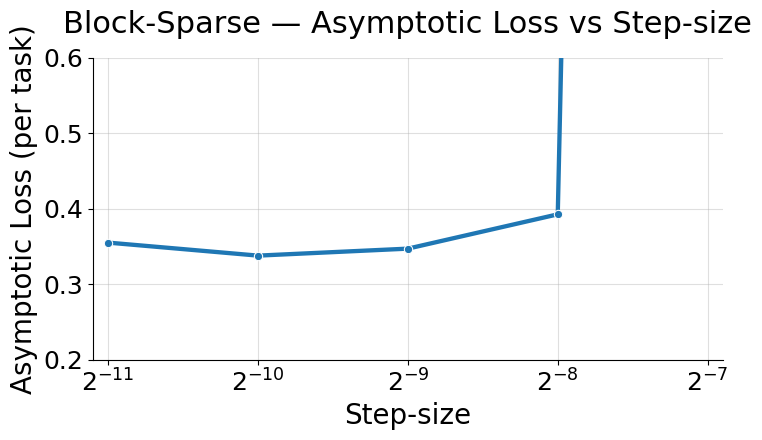

In [7]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.2, 0.6)
plt.tight_layout()
save_fig('wp_scaling_bs_lr_sensitivity_loss_stationary')
plt.show()


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


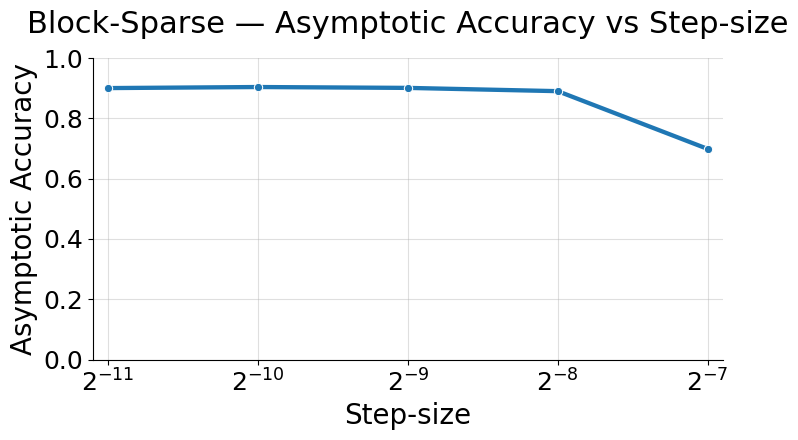

In [8]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_bs_lr_sensitivity_acc_stationary')
plt.show()


### Dense: step-size sensitivity (hue = hidden units)

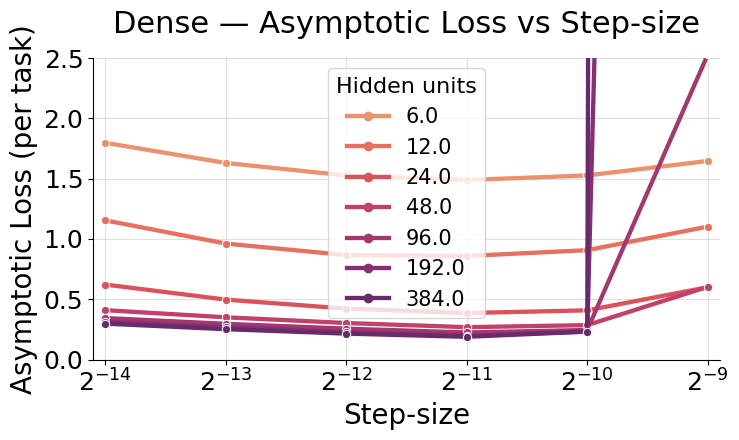

In [9]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 2.5)
plt.tight_layout()
save_fig('wp_scaling_dense_lr_sensitivity_loss_stationary')
plt.show()


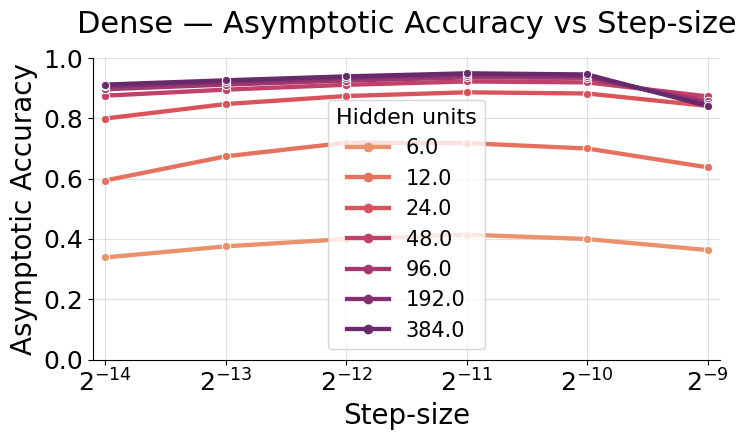

In [10]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_dense_lr_sensitivity_acc_stationary')
plt.show()


### Asymptotic performance vs model size (best step-size per size)

The dotted horizontal line marks the asymptotic block-sparse performance at its best
step-size — a fixed-budget reference for the dense scaling curve.

In [11]:
# Best LR per dense size, on each metric.
de_best_loss_cfg, de_best_loss_run, de_best_loss = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='loss_per_task',
)
de_best_acc_cfg,  de_best_acc_run,  de_best_acc  = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='accuracy',
    direction='max',
)

# Block-sparse asymptotic at its best LR (single value per metric).
bs_asym_loss = asymptotic_metric(bs_cfg, bs_run, 'loss_per_task', group_cols=[])
bs_best_loss_value = bs_asym_loss['_metric'].min()
bs_best_loss_lr = bs_asym_loss.loc[bs_asym_loss['_metric'].idxmin(), 'optimizer.learning_rate']

bs_asym_acc = asymptotic_metric(bs_cfg, bs_run, 'accuracy', group_cols=[])
bs_best_acc_value = bs_asym_acc['_metric'].max()
bs_best_acc_lr = bs_asym_acc.loc[bs_asym_acc['_metric'].idxmax(), 'optimizer.learning_rate']

print(f'Block-Sparse best step-size (loss):     2^{int(np.log2(bs_best_loss_lr)):d}  '
      f'-> asymptotic loss/task = {bs_best_loss_value:.4f}')
print(f'Block-Sparse best step-size (accuracy): 2^{int(np.log2(bs_best_acc_lr)):d}  '
      f'-> asymptotic accuracy = {bs_best_acc_value:.4f}')
print()
print('Dense per-size best step-size (loss):')
print(de_best_loss[['model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))


Block-Sparse best step-size (loss):     2^-10  -> asymptotic loss/task = 0.3378
Block-Sparse best step-size (accuracy): 2^-10  -> asymptotic accuracy = 0.9037

Dense per-size best step-size (loss):
 model.initial_hidden_units  optimizer.learning_rate  _metric
                        6.0                 0.000488 1.488455
                       12.0                 0.000488 0.858100
                       24.0                 0.000488 0.385140
                       48.0                 0.000488 0.268256
                       96.0                 0.000488 0.224221
                      192.0                 0.000488 0.198846
                      384.0                 0.000488 0.188430


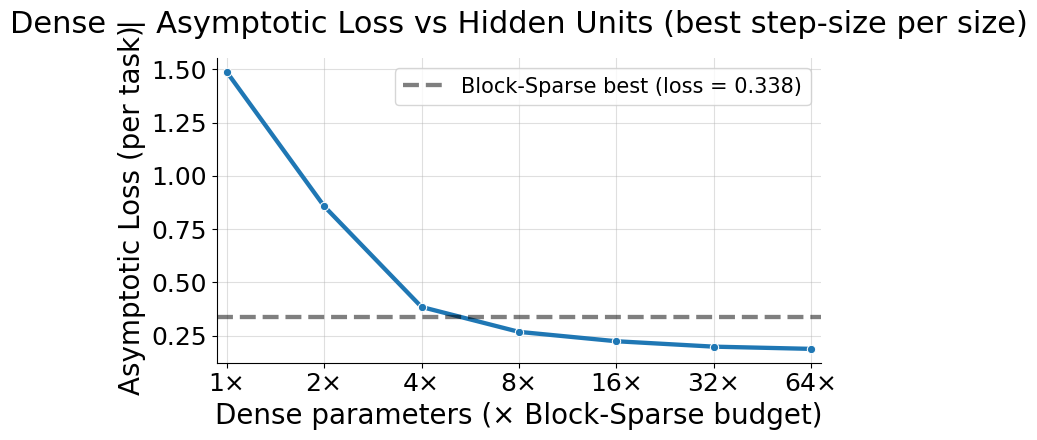

In [12]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_loss_run, config_df=de_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Loss vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_loss_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (loss = {bs_best_loss_value:.3f})')
relabel_size_axis()
plt.legend()
plt.tight_layout()
save_fig('wp_scaling_dense_size_loss_stationary')
plt.show()


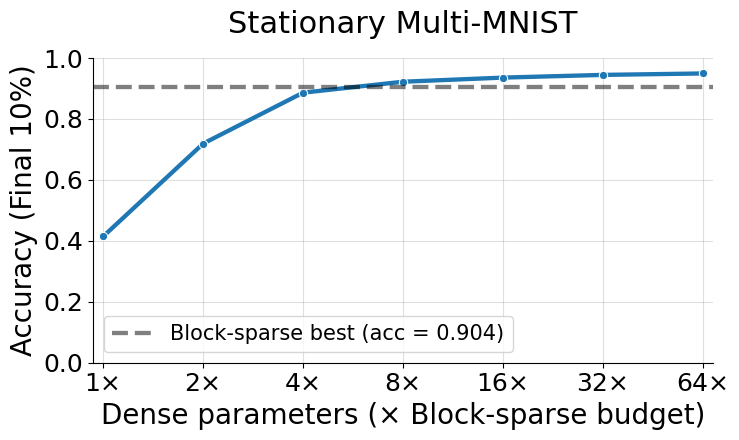

In [13]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_acc_run, config_df=de_best_acc_cfg,
    x_col='model.initial_hidden_units',
    title='Stationary Multi-MNIST',
    x_label='Dense parameters (× Block-sparse budget)', y_label='Accuracy (Final 10%)',
    metric_col='accuracy', metric_type='final_avg',
    nan_policy='propagate',
)
plt.axhline(bs_best_acc_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-sparse best (acc = {bs_best_acc_value:.3f})')
plt.ylim(0.0, 1.0)
relabel_size_axis()
plt.legend()
plt.tight_layout()
save_fig('wp_scaling_dense_size_acc_stationary')
plt.show()


---
## 2. Non-Stationary  (`permute_period = 4000`)  (sweep_name prefix `02_`)

In [14]:
sec_cfg, sec_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('02b_') and k.endswith('_lr'),
)
bs_cfg = sec_cfg[sec_cfg['Method'] == 'Block-Sparse'].copy()
bs_run = sec_run[sec_run['run_id'].isin(bs_cfg['run_id'])].copy()
de_cfg = sec_cfg[sec_cfg['Method'] == 'Dense'].copy()
de_run = sec_run[sec_run['run_id'].isin(de_cfg['run_id'])].copy()
print(f'Block-Sparse rows: {len(bs_cfg)}  |  Dense rows: {len(de_cfg)} '
      f'({de_cfg["model.initial_hidden_units"].nunique()} sizes × '
      f'{de_cfg["optimizer.learning_rate"].nunique()} step-sizes)')


Block-Sparse rows: 5  |  Dense rows: 42 (7 sizes × 6 step-sizes)


### Block-sparse: step-size sensitivity

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


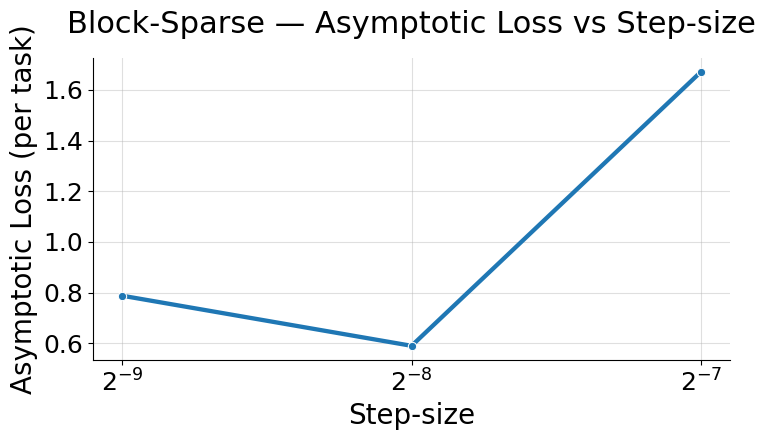

In [15]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.tight_layout()
save_fig('wp_scaling_bs_lr_sensitivity_loss_nonstationary')
plt.show()


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


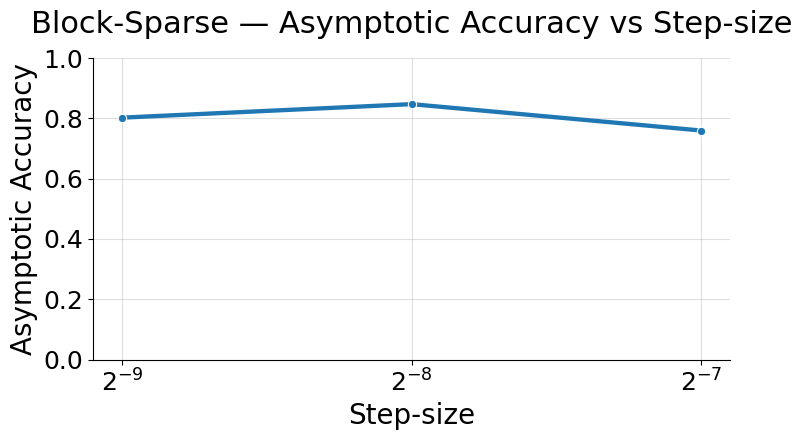

In [16]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_bs_lr_sensitivity_acc_nonstationary')
plt.show()


### Dense: step-size sensitivity (hue = hidden units)

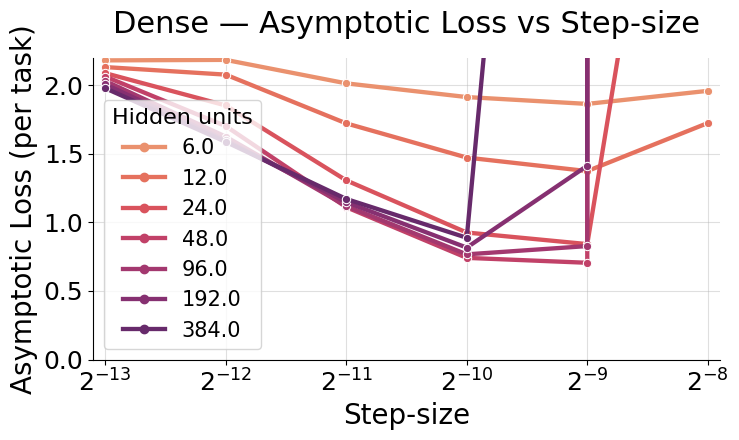

In [17]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 2.2)
plt.tight_layout()
save_fig('wp_scaling_dense_lr_sensitivity_loss_nonstationary')
plt.show()


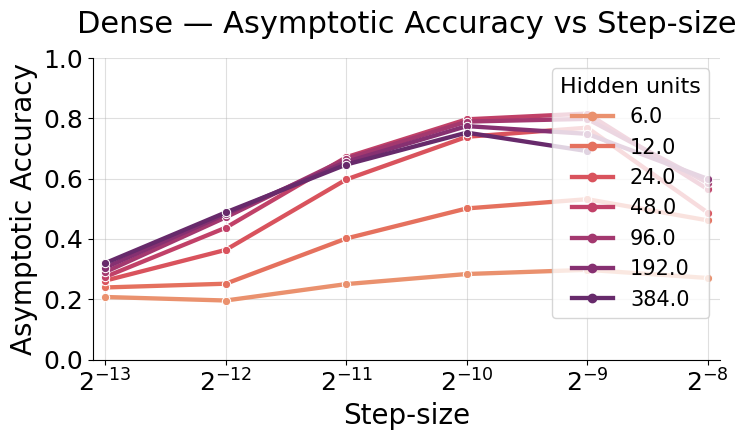

In [18]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_dense_lr_sensitivity_acc_nonstationary')
plt.show()


### Asymptotic performance vs model size (best step-size per size)

The dotted horizontal line marks the asymptotic block-sparse performance at its best
step-size — a fixed-budget reference for the dense scaling curve.

In [19]:
# Best LR per dense size, on each metric.
de_best_loss_cfg, de_best_loss_run, de_best_loss = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='loss_per_task',
)
de_best_acc_cfg,  de_best_acc_run,  de_best_acc  = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='accuracy',
    direction='max',
)

# Block-sparse asymptotic at its best LR (single value per metric).
bs_asym_loss = asymptotic_metric(bs_cfg, bs_run, 'loss_per_task', group_cols=[])
bs_best_loss_value = bs_asym_loss['_metric'].min()
bs_best_loss_lr = bs_asym_loss.loc[bs_asym_loss['_metric'].idxmin(), 'optimizer.learning_rate']

bs_asym_acc = asymptotic_metric(bs_cfg, bs_run, 'accuracy', group_cols=[])
bs_best_acc_value = bs_asym_acc['_metric'].max()
bs_best_acc_lr = bs_asym_acc.loc[bs_asym_acc['_metric'].idxmax(), 'optimizer.learning_rate']

print(f'Block-Sparse best step-size (loss):     2^{int(np.log2(bs_best_loss_lr)):d}  '
      f'-> asymptotic loss/task = {bs_best_loss_value:.4f}')
print(f'Block-Sparse best step-size (accuracy): 2^{int(np.log2(bs_best_acc_lr)):d}  '
      f'-> asymptotic accuracy = {bs_best_acc_value:.4f}')
print()
print('Dense per-size best step-size (loss):')
print(de_best_loss[['model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))


Block-Sparse best step-size (loss):     2^-8  -> asymptotic loss/task = 0.5902
Block-Sparse best step-size (accuracy): 2^-8  -> asymptotic accuracy = 0.8470

Dense per-size best step-size (loss):
 model.initial_hidden_units  optimizer.learning_rate  _metric
                        6.0                 0.001953 1.865044
                       12.0                 0.001953 1.374765
                       24.0                 0.001953 0.842114
                       48.0                 0.001953 0.705836
                       96.0                 0.000977 0.767364
                      192.0                 0.000977 0.816597
                      384.0                 0.000977 0.888417


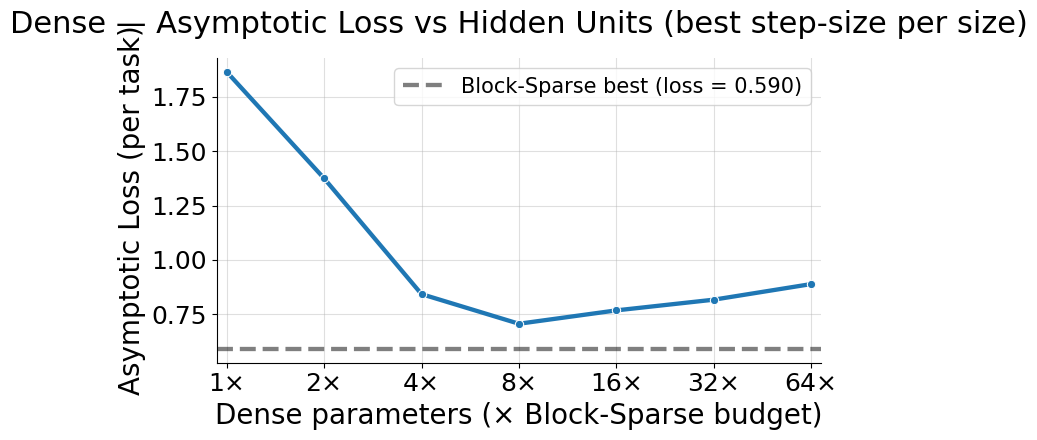

In [20]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_loss_run, config_df=de_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Loss vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_loss_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (loss = {bs_best_loss_value:.3f})')
relabel_size_axis()
plt.legend()
plt.tight_layout()
save_fig('wp_scaling_dense_size_loss_nonstationary')
plt.show()


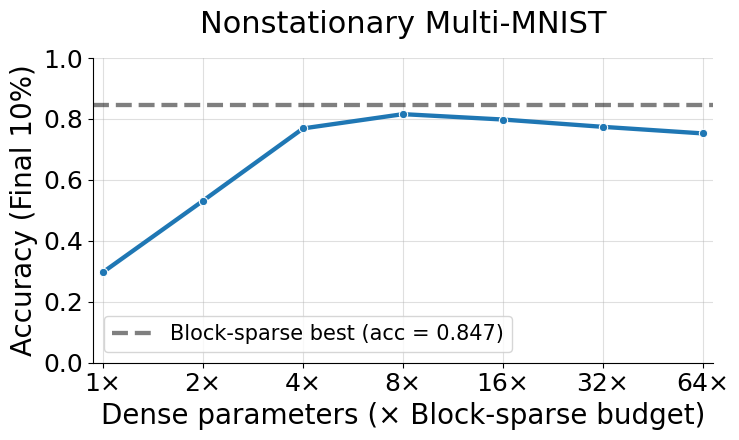

In [21]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_acc_run, config_df=de_best_acc_cfg,
    x_col='model.initial_hidden_units',
    title='Nonstationary Multi-MNIST',
    x_label='Dense parameters (× Block-sparse budget)', y_label='Accuracy (Final 10%)',
    metric_col='accuracy', metric_type='final_avg',
    nan_policy='propagate',
)

plt.axhline(bs_best_acc_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-sparse best (acc = {bs_best_acc_value:.3f})')
plt.ylim(0.0, 1.0)
relabel_size_axis()
plt.legend()
plt.tight_layout()
save_fig('wp_scaling_dense_size_acc_nonstationary')
plt.show()


### Best-config learning curves

Block-Sparse at its best step-size, vs Dense at its best (size, step-size) combo.

In [22]:
# Best dense (size, lr) by loss.
de_loss_pair = de_best_loss.loc[de_best_loss['_metric'].idxmin()]
de_best_size = int(de_loss_pair['model.initial_hidden_units'])
de_best_lr = float(de_loss_pair['optimizer.learning_rate'])
print(f'Best Dense (loss): {de_best_size} hidden units @ '
      f'2^{int(np.log2(de_best_lr)):d} -> loss/task = {de_loss_pair["_metric"]:.4f}')

bs_keep = bs_cfg[np.isclose(bs_cfg['optimizer.learning_rate'], bs_best_loss_lr)]
de_keep = de_cfg[
    (de_cfg['model.initial_hidden_units'] == de_best_size)
    & np.isclose(de_cfg['optimizer.learning_rate'], de_best_lr)
]
keep_cfg = pd.concat([bs_keep, de_keep], ignore_index=True)
keep_run = sec_run[sec_run['run_id'].isin(keep_cfg['run_id'])].copy()
print(f'Combined per-seed runs for learning curves: {len(keep_cfg)} '
      f'({len(bs_keep)} block-sparse + {len(de_keep)} dense)')


Best Dense (loss): 48 hidden units @ 2^-9 -> loss/task = 0.7058
Combined per-seed runs for learning curves: 2 (1 block-sparse + 1 dense)


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


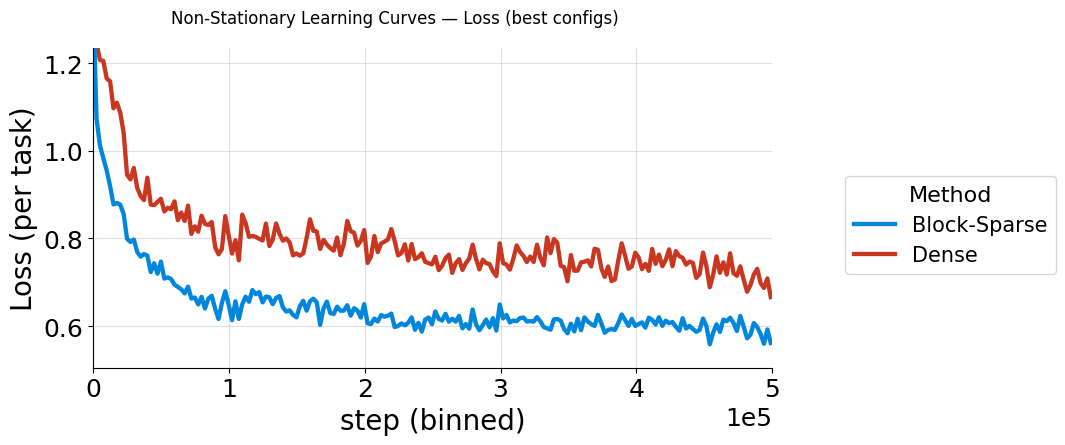

In [23]:
plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='loss_per_task', y_label='Loss (per task)',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Loss (best configs)')
plt.tight_layout()
save_fig('wp_scaling_learning_curves_loss_nonstationary')
plt.show()


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


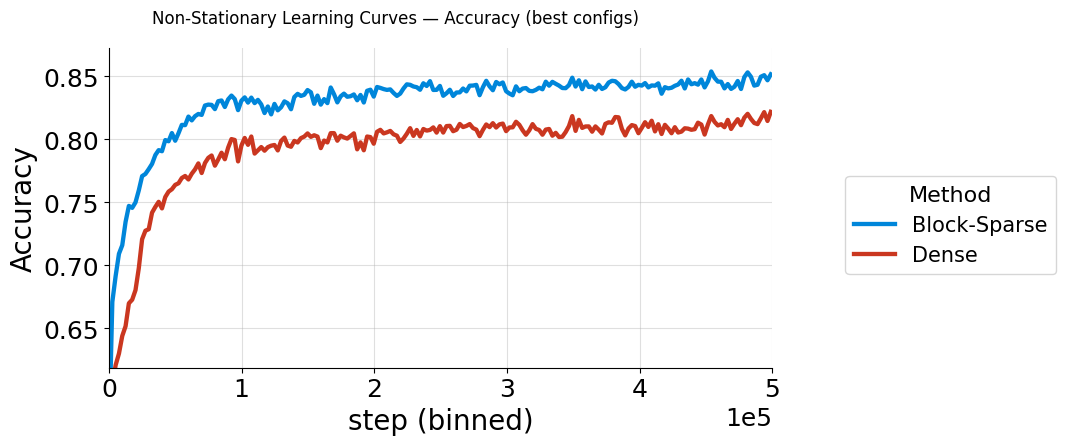

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


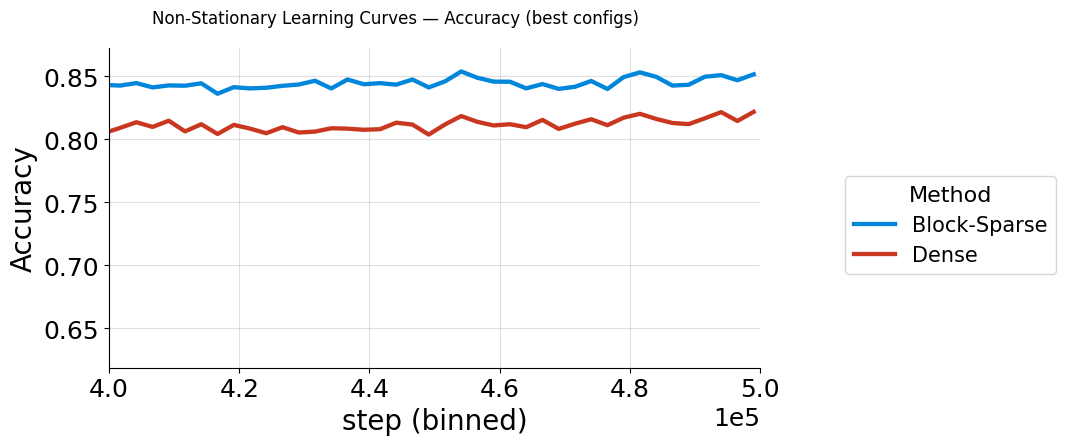

In [24]:
plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='accuracy', y_label='Accuracy',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Accuracy (best configs)')
plt.tight_layout()
save_fig('wp_scaling_learning_curves_acc_nonstationary')
plt.show()

plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    figsize=(8, 4.5),
    y_col='accuracy', y_label='Accuracy',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Accuracy (best configs)')
plt.xlim(400_000, 500_000)
plt.tight_layout()
save_fig('wp_scaling_learning_curves_acc_zoom_nonstationary')
plt.show()


---
## 3. Joint n_tasks × hidden scaling (sweep prefix `00_`)

Single-seed joint scan from `00_dense_n_task_scaling_lr` /
`00_block_sparse_n_task_scaling_lr`: `task.n_tasks ∈ {2, 4, 8, 16, 32}` ×
`model.initial_hidden_units ∈ {4, 8, 16, 32, 64, 128, 256}` × 4 LRs each. For
each (hidden, n_tasks) cell we plot the asymptotic accuracy of the best
learning rate.

If these sweeps aren't yet in the loaded buckets, re-run the
`download_experiment(...)` cell at the top of the notebook.

In [36]:
sec_cfg, sec_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('00_') and k.endswith('_n_task_scaling_lr_v2'),
)
bs_cfg = sec_cfg[sec_cfg['Method'] == 'Block-Sparse'].copy()
bs_run = sec_run[sec_run['run_id'].isin(bs_cfg['run_id'])].copy()
de_cfg = sec_cfg[sec_cfg['Method'] == 'Dense'].copy()
de_run = sec_run[sec_run['run_id'].isin(de_cfg['run_id'])].copy()
print(f'Block-Sparse rows: {len(bs_cfg)}  |  Dense rows: {len(de_cfg)}')
print(f'  n_tasks values: {sorted(sec_cfg["task.n_tasks"].dropna().unique())}')
print(f'  hidden values: {sorted(sec_cfg["model.initial_hidden_units"].dropna().unique())}')

# Sequential palette over n_tasks (powers of 2: 2, 4, 8, 16, 32).
N_TASKS_VALUES = sorted(sec_cfg['task.n_tasks'].dropna().unique())
N_TASKS_PALETTE = dict(zip(
    N_TASKS_VALUES,
    sns.color_palette('viridis', n_colors=len(N_TASKS_VALUES)),
))

Block-Sparse rows: 112  |  Dense rows: 96
  n_tasks values: [2.0, 4.0, 8.0, 16.0, 32.0]
  hidden values: [4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0]


In [37]:
# Best LR per (hidden, n_tasks) by accuracy.
de_best_cfg, de_best_run, de_best = filter_to_best(
    de_cfg, de_run,
    group_cols=['model.initial_hidden_units', 'task.n_tasks'],
    metric_col='accuracy', direction='max',
)
bs_best_cfg, bs_best_run, bs_best = filter_to_best(
    bs_cfg, bs_run,
    group_cols=['model.initial_hidden_units', 'task.n_tasks'],
    metric_col='accuracy', direction='max',
)
print('Dense  — best LR per (hidden, n_tasks):')
print(de_best.sort_values(['task.n_tasks', 'model.initial_hidden_units'])
      [['task.n_tasks', 'model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))
print()
print('Block-Sparse — best LR per (hidden, n_tasks):')
print(bs_best.sort_values(['task.n_tasks', 'model.initial_hidden_units'])
      [['task.n_tasks', 'model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))

Dense  — best LR per (hidden, n_tasks):
 task.n_tasks  model.initial_hidden_units  optimizer.learning_rate  _metric
          2.0                         4.0                 0.001953 0.329596
          2.0                         8.0                 0.001953 0.593750
          2.0                        16.0                 0.001953 0.775942
          2.0                        32.0                 0.001953 0.792058
          2.0                        64.0                 0.001953 0.784942
          2.0                       128.0                 0.001953 0.760538
          2.0                       256.0                 0.001953 0.749135
          4.0                         4.0                 0.001953 0.200856
          4.0                         8.0                 0.001953 0.330192
          4.0                        16.0                 0.001953 0.573442
          4.0                        32.0                 0.001953 0.743683
          4.0                        64.0       

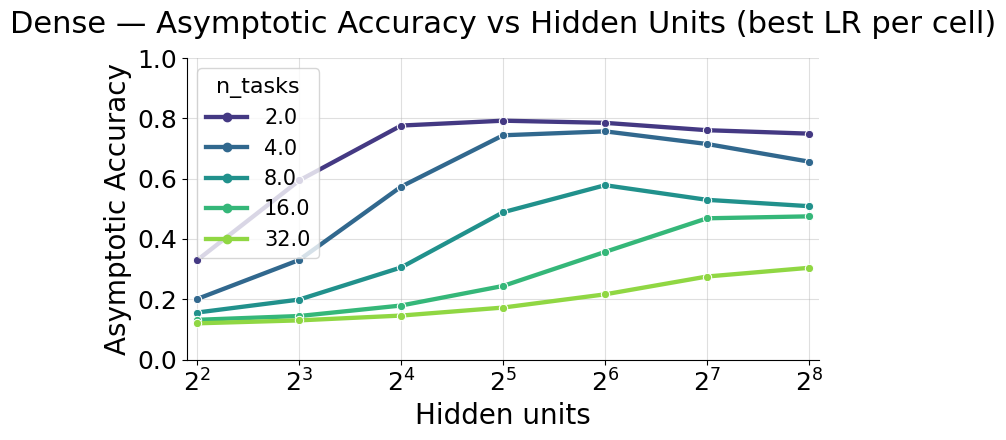

In [38]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_run, config_df=de_best_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Accuracy vs Hidden Units (best LR per cell)',
    x_label='Hidden units', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='task.n_tasks', legend_title='n_tasks',
    palette=N_TASKS_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_dense_hidden_vs_ntasks_acc')
plt.show()

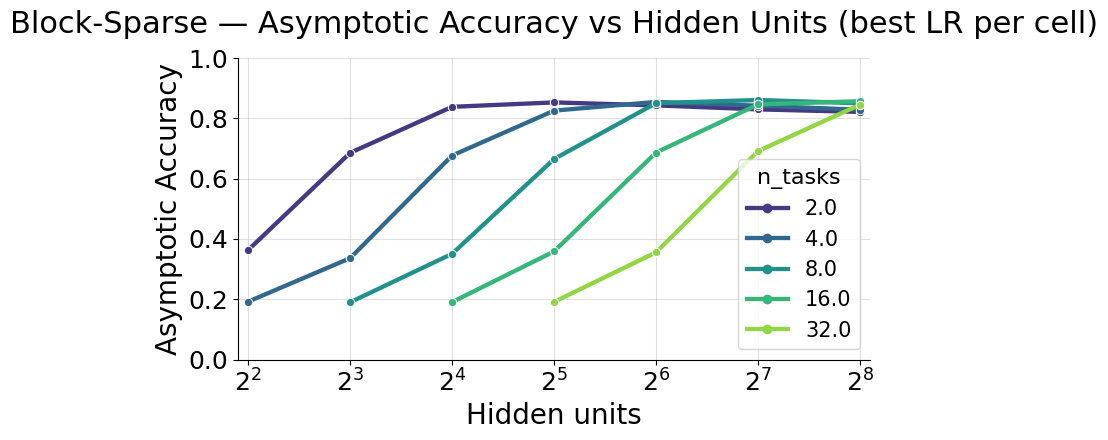

In [ ]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_best_run, config_df=bs_best_cfg,
    x_col='model.initial_hidden_units',
    title='Block-Sparse — Asymptotic Accuracy vs Hidden Units (best LR per cell)',
    x_label='Hidden units', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='task.n_tasks', legend_title='n_tasks',
    palette=N_TASKS_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
save_fig('wp_scaling_bs_hidden_vs_ntasks_acc')
plt.show()

### Loss versions (best LR per cell)

In [40]:
# Best LR per (hidden, n_tasks) by loss (per task, so curves are comparable
# across n_tasks values).
de_best_loss_cfg, de_best_loss_run, de_best_loss = filter_to_best(
    de_cfg, de_run,
    group_cols=['model.initial_hidden_units', 'task.n_tasks'],
    metric_col='loss_per_task', direction='min',
)
bs_best_loss_cfg, bs_best_loss_run, bs_best_loss = filter_to_best(
    bs_cfg, bs_run,
    group_cols=['model.initial_hidden_units', 'task.n_tasks'],
    metric_col='loss_per_task', direction='min',
)
print('Dense  — best LR per (hidden, n_tasks):')
print(de_best_loss.sort_values(['task.n_tasks', 'model.initial_hidden_units'])
      [['task.n_tasks', 'model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))
print()
print('Block-Sparse — best LR per (hidden, n_tasks):')
print(bs_best_loss.sort_values(['task.n_tasks', 'model.initial_hidden_units'])
      [['task.n_tasks', 'model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))

Dense  — best LR per (hidden, n_tasks):
 task.n_tasks  model.initial_hidden_units  optimizer.learning_rate  _metric
          2.0                         4.0                 0.001953 1.865216
          2.0                         8.0                 0.001953 1.317110
          2.0                        16.0                 0.001953 0.822374
          2.0                        32.0                 0.001953 0.770101
          2.0                        64.0                 0.001953 0.802117
          2.0                       128.0                 0.001953 0.882394
          2.0                       256.0                 0.001953 0.918097
          4.0                         4.0                 0.001953 2.101884
          4.0                         8.0                 0.001953 1.837258
          4.0                        16.0                 0.001953 1.347017
          4.0                        32.0                 0.001953 0.929421
          4.0                        64.0       

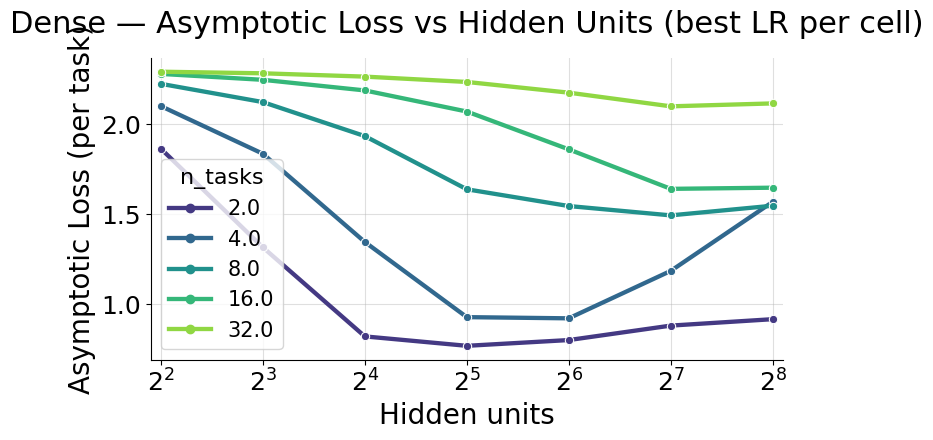

In [41]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_loss_run, config_df=de_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Loss vs Hidden Units (best LR per cell)',
    x_label='Hidden units', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='task.n_tasks', legend_title='n_tasks',
    palette=N_TASKS_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.tight_layout()
save_fig('wp_scaling_dense_hidden_vs_ntasks_loss')
plt.show()

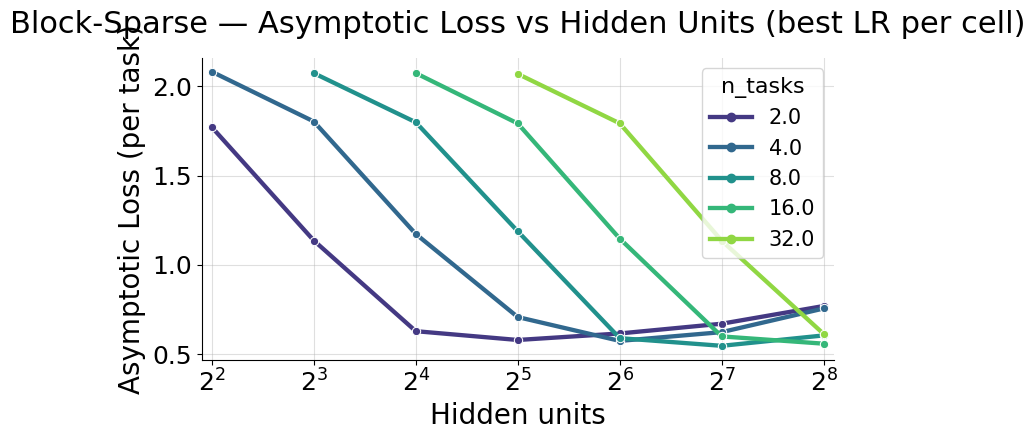

In [42]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_best_loss_run, config_df=bs_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Block-Sparse — Asymptotic Loss vs Hidden Units (best LR per cell)',
    x_label='Hidden units', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='task.n_tasks', legend_title='n_tasks',
    palette=N_TASKS_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.tight_layout()
save_fig('wp_scaling_bs_hidden_vs_ntasks_loss')
plt.show()

### LR-sensitivity grid (rows = n_tasks, cols = hidden)

Each panel plots asymptotic accuracy vs learning rate for one
`(n_tasks, hidden)` cell. The red star marks the best LR for that cell —
the same LR used as the corresponding point in the summary plots above.
Empty panels are infeasible combinations (block-sparse with
`hidden < n_tasks`).

In [43]:
def plot_lr_sensitivity_grid(
    cfg, run, *,
    metric_col, metric_label, direction, ylim, title, savename,
):
    """Grid of (n_tasks × hidden) panels, each plotting metric vs LR.

    direction='max' marks the highest value with a red star (use for accuracy);
    direction='min' marks the lowest (use for loss). Cells with no data are
    rendered as empty axes with a light "—" placeholder.
    """
    asym = asymptotic_metric(
        cfg, run, metric_col,
        group_cols=['task.n_tasks', 'model.initial_hidden_units'],
    )
    n_tasks_vals = sorted(asym['task.n_tasks'].dropna().unique())
    hidden_vals = sorted(asym['model.initial_hidden_units'].dropna().unique())
    nrows, ncols = len(n_tasks_vals), len(hidden_vals)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(1.6 * ncols + 1.0, 1.5 * nrows + 0.6),
        sharex=True, sharey=True, squeeze=False,
    )
    for i, nt in enumerate(n_tasks_vals):
        for j, h in enumerate(hidden_vals):
            ax = axes[i, j]
            sub = asym[
                (asym['task.n_tasks'] == nt)
                & (asym['model.initial_hidden_units'] == h)
            ].sort_values('optimizer.learning_rate')
            if len(sub) == 0:
                ax.text(0.5, 0.5, '—', ha='center', va='center',
                        transform=ax.transAxes, color='lightgray', fontsize=14)
            else:
                xs = np.log2(sub['optimizer.learning_rate'].astype(float))
                ys = sub['_metric'].values
                ax.plot(xs, ys, '-o', markersize=4, color='C0')
                best = sub.loc[sub['_metric'].idxmax() if direction == 'max'
                               else sub['_metric'].idxmin()]
                ax.plot(np.log2(float(best['optimizer.learning_rate'])),
                        best['_metric'], '*', color='red', markersize=11,
                        markeredgecolor='black', markeredgewidth=0.5)
            if i == 0:
                ax.set_title(f'h={int(h)}', fontsize=9)
            if j == 0:
                ax.set_ylabel(f'n={int(nt)}', fontsize=9)
            if i == nrows - 1:
                ax.set_xlabel(r'$\log_2$ LR', fontsize=8)
            ax.tick_params(labelsize=7)
            if ylim is not None:
                ax.set_ylim(ylim)
            ax.grid(True, alpha=0.3)
    fig.suptitle(title, y=1.0)
    fig.supylabel(metric_label, fontsize=10)
    fig.tight_layout()
    save_fig(savename)
    plt.show()

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


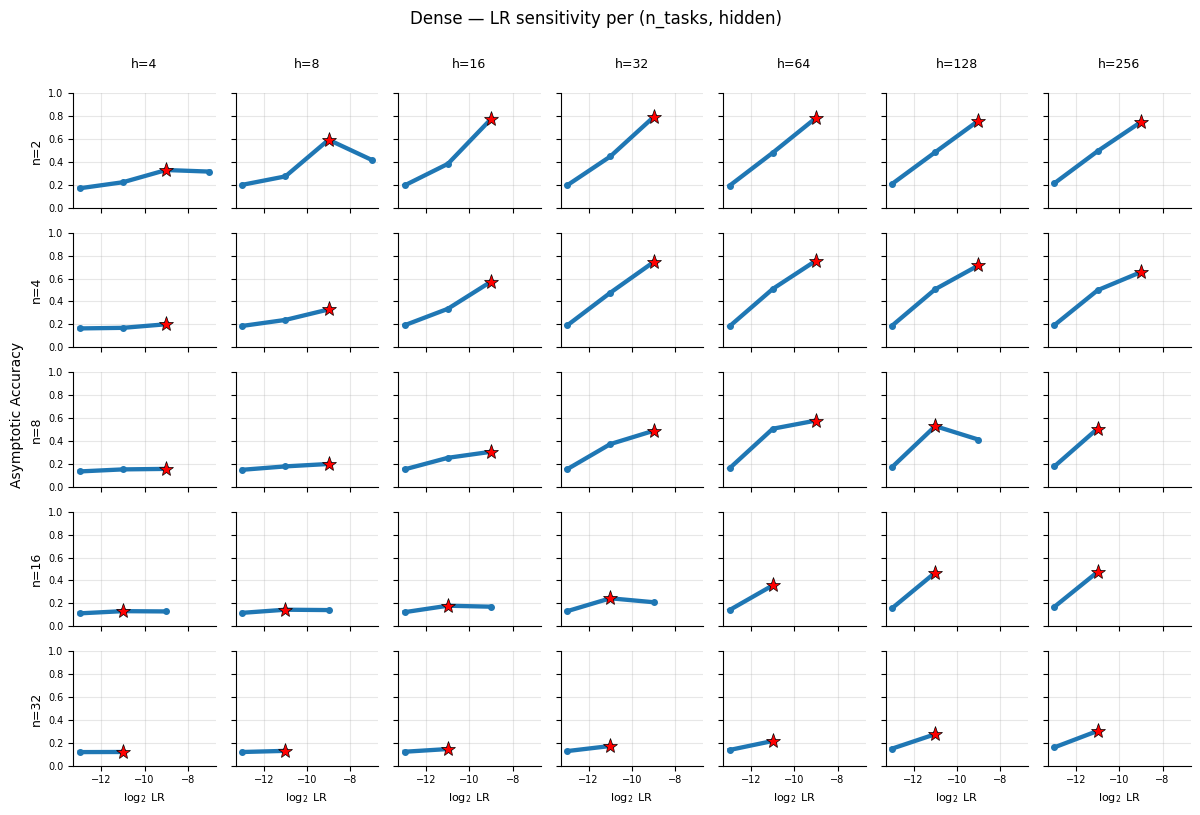

In [44]:
plot_lr_sensitivity_grid(
    de_cfg, de_run,
    metric_col='accuracy', metric_label='Asymptotic Accuracy',
    direction='max', ylim=(0.0, 1.0),
    title='Dense — LR sensitivity per (n_tasks, hidden)',
    savename='wp_scaling_dense_lr_grid_acc',
)

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:241: UserWarning: No legend found
  warnings.warn('No legend found')


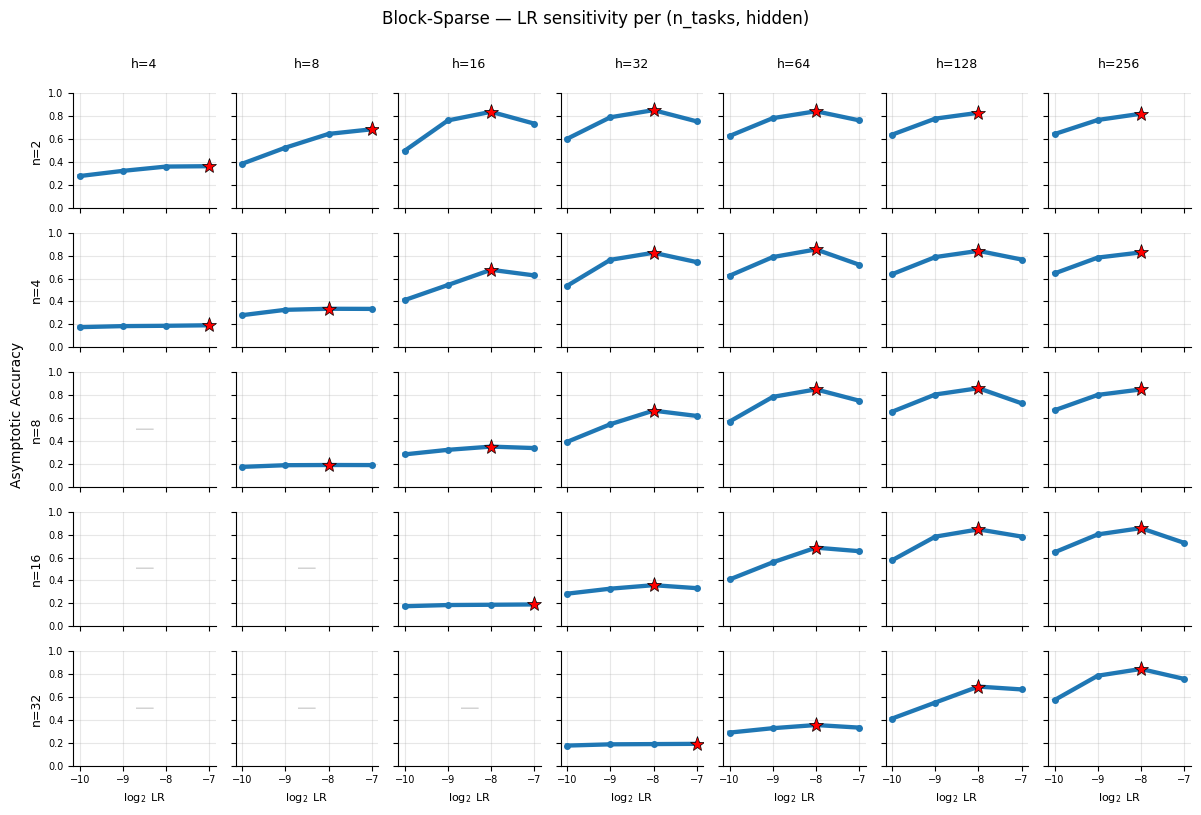

In [45]:
plot_lr_sensitivity_grid(
    bs_cfg, bs_run,
    metric_col='accuracy', metric_label='Asymptotic Accuracy',
    direction='max', ylim=(0.0, 1.0),
    title='Block-Sparse — LR sensitivity per (n_tasks, hidden)',
    savename='wp_scaling_bs_lr_grid_acc',
)

### Learning-curve grid (rows = n_tasks, cols = hidden)

For each `(n_tasks, hidden)` cell, plot the full learning curve of **Dense**
and **Block-Sparse** side-by-side, with each method using its own best
step-size for that cell (filtered upstream into
`de_best_*` / `bs_best_*`). Empty panels indicate infeasible combinations
(e.g. block-sparse with `hidden < n_tasks`).

In [46]:
def plot_learning_curve_grid(
    de_cfg, de_run, bs_cfg, bs_run, *,
    y_col, y_label, title, savename, ylim=None, n_bins=100,
):
    """Grid of (n_tasks × hidden) panels with Dense + Block-Sparse learning curves.

    Each method's cfg/run inputs should already be filtered to its best LR per
    (n_tasks, hidden) cell — i.e. produced by `filter_to_best(..., group_cols=
    ['model.initial_hidden_units', 'task.n_tasks'], ...)`.
    """
    all_cfg = pd.concat([de_cfg, bs_cfg], ignore_index=True)
    n_tasks_vals = sorted(all_cfg['task.n_tasks'].dropna().unique())
    hidden_vals = sorted(all_cfg['model.initial_hidden_units'].dropna().unique())
    nrows, ncols = len(n_tasks_vals), len(hidden_vals)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(1.8 * ncols + 1.0, 1.6 * nrows + 0.6),
        sharex=True, sharey=True, squeeze=False,
    )

    for i, nt in enumerate(n_tasks_vals):
        for j, h in enumerate(hidden_vals):
            ax = axes[i, j]
            plotted = False
            for method, mcfg, mrun in [
                ('Dense', de_cfg, de_run),
                ('Block-Sparse', bs_cfg, bs_run),
            ]:
                cell_cfg = mcfg[
                    (mcfg['task.n_tasks'] == nt)
                    & (mcfg['model.initial_hidden_units'] == h)
                ]
                if len(cell_cfg) == 0:
                    continue
                cell_run = mrun[mrun['run_id'].isin(cell_cfg['run_id'])]
                if len(cell_run) == 0:
                    continue
                binned = bin_df(cell_run, n_bins=n_bins, groupby_cols=[])
                ax.plot(
                    binned['step'], binned[y_col],
                    color=METHOD_PALETTE[method], label=method, linewidth=1.2,
                )
                plotted = True

            if not plotted:
                ax.text(0.5, 0.5, '—', ha='center', va='center',
                        transform=ax.transAxes, color='lightgray', fontsize=14)

            if i == 0:
                ax.set_title(f'h={int(h)}', fontsize=9)
            if j == 0:
                ax.set_ylabel(f'n={int(nt)}', fontsize=9)
            if i == nrows - 1:
                ax.set_xlabel('step', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
            if ylim is not None:
                ax.set_ylim(ylim)
            ax.grid(True, alpha=0.3)

    handles = [plt.Line2D([0], [0], color=METHOD_PALETTE[m], label=m, linewidth=1.5)
               for m in METHOD_ORDER]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9)

    fig.suptitle(title, y=1.0)
    fig.supylabel(y_label, fontsize=10)
    fig.tight_layout()
    save_fig(savename)
    plt.show()

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[bin_var] = pd.cut(df[bin_var], bins=bins, labels=labels)
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[bin_var] = pd.cut(df[bin_var], bins=bins, labels=labels)
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value 

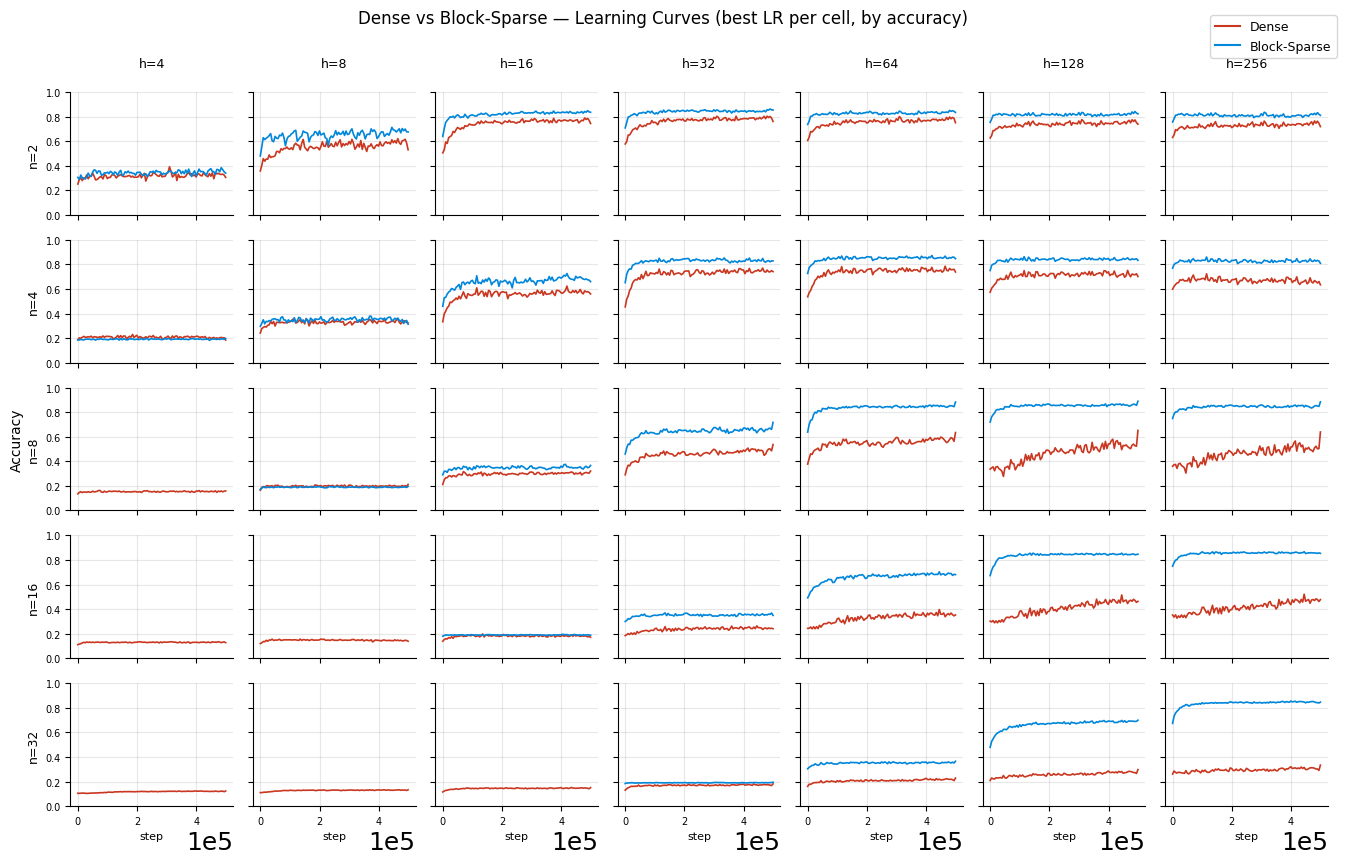

In [47]:
plot_learning_curve_grid(
    de_best_cfg, de_best_run, bs_best_cfg, bs_best_run,
    y_col='accuracy', y_label='Accuracy',
    title='Dense vs Block-Sparse — Learning Curves (best LR per cell, by accuracy)',
    savename='wp_scaling_learning_curve_grid_acc',
    ylim=(0.0, 1.0),
)

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[bin_var] = pd.cut(df[bin_var], bins=bins, labels=labels)
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[bin_var] = pd.cut(df[bin_var], bins=bins, labels=labels)
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:36: SettingWithCopyWarning: 
A value 

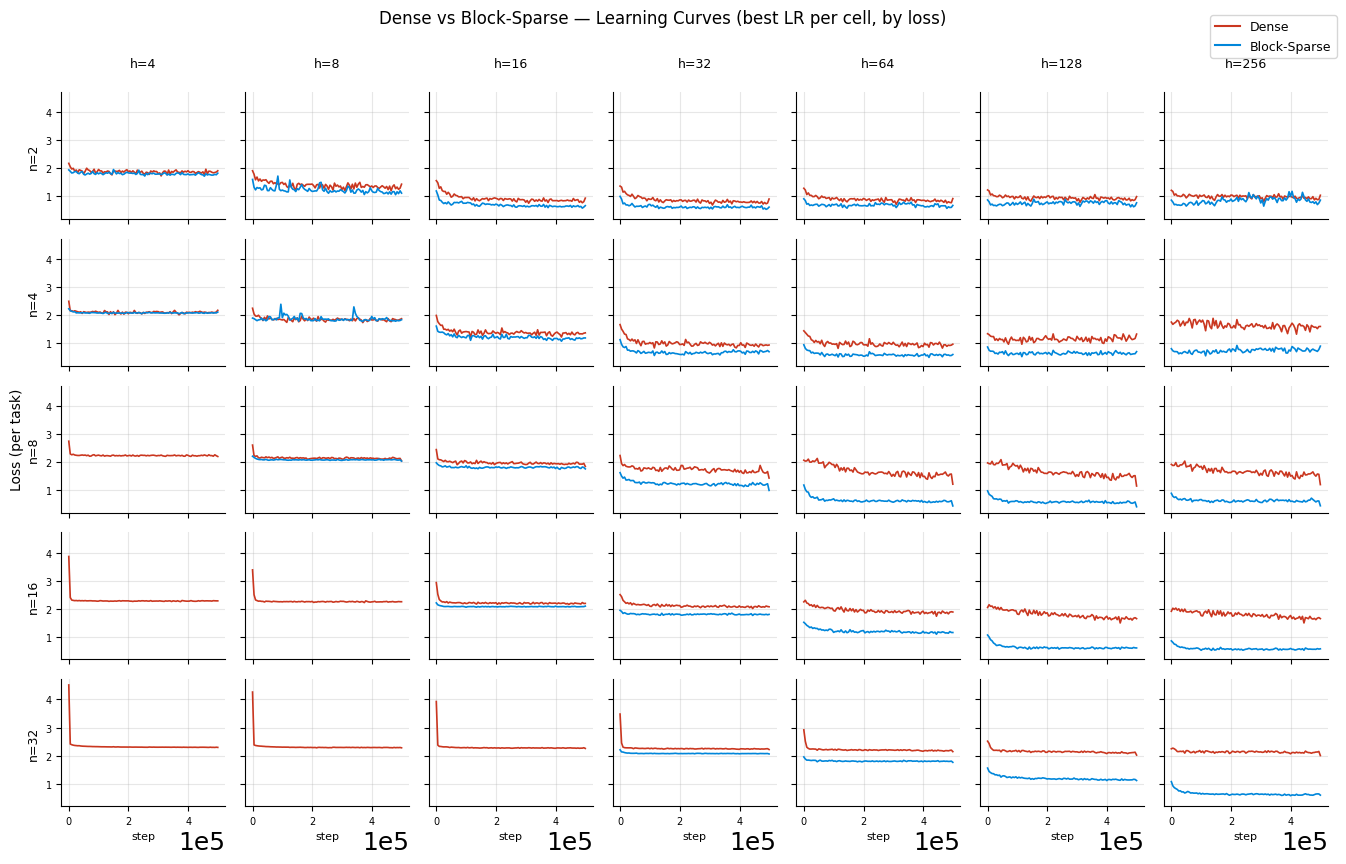

In [48]:
plot_learning_curve_grid(
    de_best_loss_cfg, de_best_loss_run, bs_best_loss_cfg, bs_best_loss_run,
    y_col='loss_per_task', y_label='Loss (per task)',
    title='Dense vs Block-Sparse — Learning Curves (best LR per cell, by loss)',
    savename='wp_scaling_learning_curve_grid_loss',
)